# Paper ablation comparison — MVP equity CSVs

Loads outputs from ``scripts/backtest_mvp_ablations.py``: ``{ablation}_{start}_{end}_{ticker_safe}.csv`` under ``results/``. Same thin schema as ``equity.csv`` (not the full ``dates.csv`` join).

**Setup:** ``pip install ".[notebooks]"`` or ``pip install matplotlib jupyter pandas`` in your venv.

In [5]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

_mpl = Path.cwd() / ".mpl_cache"
_mpl.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_mpl.resolve()))

import matplotlib

try:
    __IPYTHON__  # noqa: B018
except NameError:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings(
    "ignore", message="FigureCanvasAgg is non-interactive.*", category=UserWarning
)

try:
    from IPython.display import display
except ImportError:

    def display(obj=None, **kwargs):
        if obj is not None:
            print(obj)


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for base in (cwd, cwd.parent):
        if (base / "tradingagents").is_dir():
            return base
    return cwd


ROOT = _repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from tradingagents.backtest.metrics import (
    annualized_return,
    buy_and_hold_total_return,
    calmar_ratio,
    max_drawdown,
    sharpe_ratio,
    sortino_ratio,
)
from tradingagents.paper_ablation import PAPER_ABLATION_LABELS

for _style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    try:
        plt.style.use(_style)
        break
    except OSError:
        continue
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titlesize": 12})


def _safe_ticker_for_filename(ticker: str) -> str:
    return "".join(c if c.isalnum() or c in "-_" else "_" for c in ticker.strip())


def resolve_results_dir() -> Path:
    cwd = Path.cwd().resolve()
    for base in (cwd, cwd.parent):
        r = base / "results"
        if r.is_dir():
            return r
    return ROOT / "results"


# Match a single ablation run window (same as backtest_mvp_ablations INLINE_PARAMS / CLI).
RESULTS_DIR = resolve_results_dir()
START_DATE = "2024-05-01"
END_DATE = "2024-06-30"
TICKER = "RELIANCE.NS"
TICKER_SAFE = _safe_ticker_for_filename(TICKER)

ABLATION_ORDER = sorted(PAPER_ABLATION_LABELS)
print(f"Repo: {ROOT}")
print(f"Results: {RESULTS_DIR}")
print(f"Window: {START_DATE} .. {END_DATE}  ticker_safe={TICKER_SAFE}")

Repo: /Users/recro/OSS/hindsight2020
Results: /Users/recro/OSS/hindsight2020/results
Window: 2024-05-01 .. 2024-06-30  ticker_safe=RELIANCE_NS


In [6]:
def ablation_csv_paths(
    results: Path,
    start: str,
    end: str,
    ticker_safe: str,
) -> dict[str, Path]:
    out: dict[str, Path] = {}
    for ab in ABLATION_ORDER:
        p = results / f"{ab}_{start}_{end}_{ticker_safe}.csv"
        if p.is_file():
            out[ab] = p
        else:
            print(f"Missing: {p.name}")
    return out


PATHS = ablation_csv_paths(RESULTS_DIR, START_DATE, END_DATE, TICKER_SAFE)
if not PATHS:
    raise FileNotFoundError(
        "No ablation CSVs found. Run scripts/backtest_mvp_ablations.py for this window/ticker,"
        " or edit START_DATE, END_DATE, TICKER above."
    )


def load_ablation_dfs(paths: dict[str, Path]) -> dict[str, pd.DataFrame]:
    dfs: dict[str, pd.DataFrame] = {}
    for ab, p in paths.items():
        raw = pd.read_csv(p)
        raw.columns = [c.strip() for c in raw.columns]
        raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
        for c in ("equity", "close", "cash", "shares", "fees_day", "cumulative_fees"):
            if c in raw.columns:
                raw[c] = pd.to_numeric(raw[c], errors="coerce")
        dfs[ab] = raw.sort_values("date").reset_index(drop=True)
    return dfs


DFS = load_ablation_dfs(PATHS)
for ab, df in DFS.items():
    print(ab, PATHS[ab].name, "rows:", len(df), "cols:", list(df.columns))

a1 a1_2024-05-01_2024-06-30_RELIANCE_NS.csv rows: 43 cols: ['date', 'signal', 'close', 'cash', 'shares', 'equity', 'fees_day', 'cumulative_fees', 'processed_signal']
a2 a2_2024-05-01_2024-06-30_RELIANCE_NS.csv rows: 43 cols: ['date', 'signal', 'close', 'cash', 'shares', 'equity', 'fees_day', 'cumulative_fees', 'processed_signal']
a3 a3_2024-05-01_2024-06-30_RELIANCE_NS.csv rows: 43 cols: ['date', 'signal', 'close', 'cash', 'shares', 'equity', 'fees_day', 'cumulative_fees', 'processed_signal']
full full_2024-05-01_2024-06-30_RELIANCE_NS.csv rows: 43 cols: ['date', 'signal', 'close', 'cash', 'shares', 'equity', 'fees_day', 'cumulative_fees', 'processed_signal']


In [7]:
def equity_rows_as_dicts(df: pd.DataFrame) -> list[dict]:
    # metrics.* expect date as string YYYY-MM-DD
    rows: list[dict] = []
    for _, r in df.iterrows():
        d = r.to_dict()
        if pd.notna(d.get("date")):
            d["date"] = pd.Timestamp(d["date"]).strftime("%Y-%m-%d")
        rows.append(d)
    return rows


def summarize_ablation(ab: str, df: pd.DataFrame) -> dict:
    rows = equity_rows_as_dicts(df)
    if not rows:
        return {"ablation": ab, "note": "empty"}
    eqs = []
    for r in rows:
        v = r.get("equity")
        if v is None or (isinstance(v, float) and np.isnan(v)):
            continue
        try:
            eqs.append(float(v))
        except (TypeError, ValueError):
            continue
    if not eqs:
        return {"ablation": ab, "note": "no equity"}
    initial_eq = eqs[0]
    final_eq = eqs[-1]
    total_return = (final_eq - initial_eq) / initial_eq if initial_eq else float("nan")
    mdd = max_drawdown(eqs)
    ann = annualized_return(total_return, rows)
    bh = buy_and_hold_total_return(
        initial_eq,
        float(rows[0]["close"]),
        float(rows[-1]["close"]),
    )
    last_cum_fee = rows[-1].get("cumulative_fees")
    try:
        last_cum_fee_f = float(last_cum_fee) if last_cum_fee not in (None, "") else np.nan
    except (TypeError, ValueError):
        last_cum_fee_f = np.nan
    return {
        "ablation": ab,
        "days": len(rows),
        "initial_equity": initial_eq,
        "final_equity": final_eq,
        "total_return": total_return,
        "buy_hold_return": bh,
        "annualized_return": ann,
        "max_drawdown": mdd,
        "sharpe": sharpe_ratio(rows),
        "sortino": sortino_ratio(rows),
        "calmar": calmar_ratio(total_return, rows, max_dd=mdd),
        "cumulative_fees": last_cum_fee_f,
    }


SUMMARY = pd.DataFrame([summarize_ablation(ab, DFS[ab]) for ab in DFS])
display(SUMMARY)

,ablation,days,initial_equity,final_equity,total_return,buy_hold_return,annualized_return,max_drawdown,sharpe,sortino,calmar,cumulative_fees
0,a1,43,100000.0,111480.318358,0.114803,0.067403,0.982561,0.074902,2.375443,3.497025,13.117926,118.740600
1,a2,43,100000.0,110159.526395,0.101595,0.067403,0.839206,0.074903,2.081599,3.041333,11.203875,118.740600
2,a3,43,100000.0,89749.012379,-0.102510,0.067403,-0.493932,0.111151,-2.879637,-3.061527,-4.443796,1321.415876
3,full,43,100000.0,103026.097750,0.030261,0.067403,0.206519,0.040335,1.571354,3.016440,5.120041,2031.324940


## Equity curves

Each ablation may have a different number of rows if runs were partial vs complete; strategy lines use each file’s own dates. The dashed buy-and-hold line uses the **longest** loaded series as the calendar and close path (same initial equity as that series’ first row).

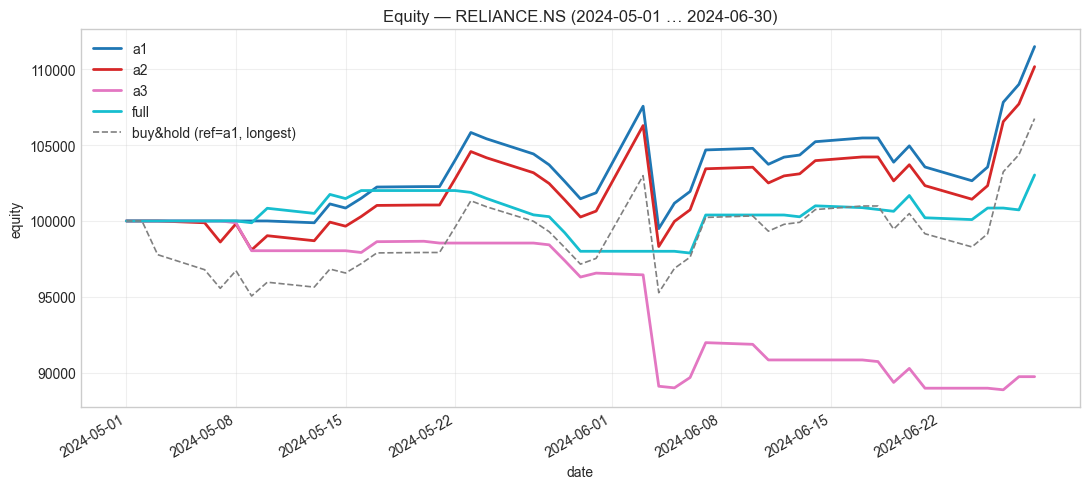

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
_colors = plt.cm.tab10(np.linspace(0, 1, max(len(DFS), 2)))
for i, ab in enumerate(DFS):
    df = DFS[ab]
    ax.plot(df["date"], df["equity"], label=ab, color=_colors[i], linewidth=2)

# Buy-and-hold benchmark: use the longest series so partial runs don’t shrink the reference window.
ref_ab = max(DFS, key=lambda k: len(DFS[k]))
ref = DFS[ref_ab]
d0 = ref.iloc[0]
init_eq = float(d0["equity"]) if pd.notna(d0["equity"]) else 100_000.0
ax.plot(
    ref["date"],
    ref["close"] / float(d0["close"]) * init_eq,
    label=f"buy&hold (ref={ref_ab}, longest)",
    color="0.5",
    linestyle="--",
    linewidth=1.2,
)

ax.set_title(f"Equity — {TICKER} ({START_DATE} … {END_DATE})")
ax.set_xlabel("date")
ax.set_ylabel("equity")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Signals on close

Same styling as ``backtest_analysis.ipynb``: black **close** line with **BUY** (green), **SELL** (red), **HOLD** (gray) dots. Uses the MVP equity column ``signal`` (falls back to ``processed_signal`` if needed).


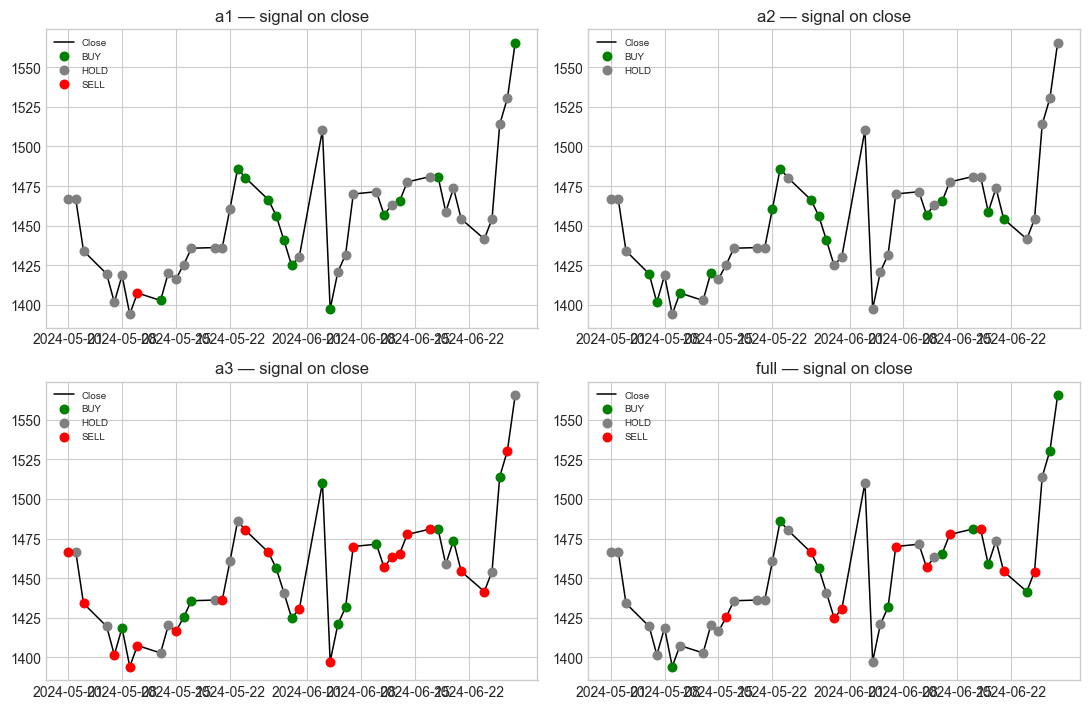

In [9]:
def _signal_series(df: pd.DataFrame) -> pd.Series:
    col = "signal" if "signal" in df.columns else "processed_signal"
    if col not in df.columns:
        raise ValueError(f"Need signal or processed_signal in columns; got {list(df.columns)}")
    return df[col].fillna("").astype(str).str.strip().str.upper()


SIGNAL_MARK_COLORS = {"BUY": "green", "SELL": "red", "HOLD": "gray"}

_ab_list = list(DFS.keys())
_n_ab = len(_ab_list)
_nrows = int(np.ceil(_n_ab / 2))
fig, axes = plt.subplots(_nrows, 2, figsize=(11, 3.6 * _nrows))
axes_flat = np.atleast_1d(axes).ravel()
for i, ab in enumerate(_ab_list):
    ax = axes_flat[i]
    df = DFS[ab]
    sig = _signal_series(df)
    tmp = df.copy()
    tmp["_sig"] = sig.values
    ax.plot(tmp["date"], tmp["close"], color="black", lw=1.1, label="Close")
    for name, g in tmp.groupby("_sig"):
        nm = str(name).upper()
        c = SIGNAL_MARK_COLORS.get(nm, "tab:blue")
        ax.scatter(g["date"], g["close"], c=c, s=38, zorder=3, label=nm)
    ax.set_title(f"{ab} — signal on close")
    ax.legend(loc="best", fontsize=7)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)
plt.tight_layout()
plt.show()


## Signal transitions (previous day → today)

Heatmaps count how often ``signal`` moves from row *t−1* to row *t* (same semantics as ``backtest_analysis.ipynb`` transition matrix).


In [ ]:
_ab_list = list(DFS.keys())
_n_ab = len(_ab_list)
_nrows = int(np.ceil(_n_ab / 2))
fig, axes = plt.subplots(_nrows, 2, figsize=(10.5, 3.3 * _nrows))
axes_flat = np.atleast_1d(axes).ravel()
for i, ab in enumerate(_ab_list):
    ax = axes_flat[i]
    df = DFS[ab]
    sig = _signal_series(df)
    prev = sig.shift(1)
    cur = sig
    trans = pd.crosstab(prev, cur, dropna=False)
    im = ax.imshow(trans.values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(trans.columns)))
    ax.set_xticklabels(trans.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(trans.index)))
    ax.set_yticklabels(trans.index, fontsize=8)
    ax.set_xlabel("signal (t)", fontsize=8)
    ax.set_ylabel("signal (t-1)", fontsize=8)
    ax.set_title(f"{ab}: transitions")
    for yi in range(trans.shape[0]):
        for xj in range(trans.shape[1]):
            ax.text(
                xj,
                yi,
                int(trans.values[yi, xj]),
                ha="center",
                va="center",
                color="black",
                fontsize=8,
            )
    plt.colorbar(im, ax=ax, fraction=0.046)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)
plt.tight_layout()
plt.show()


## Signal counts by ablation

Quick comparison of how often each disposition appears in the CSV (helps explain differing turnover and fees across presets).


In [ ]:
_rows_sig = []
_order = []
for ab in DFS:
    v = _signal_series(DFS[ab]).value_counts()
    for k in v.index:
        u = str(k).strip().upper()
        if u not in _order:
            _order.append(u)
_prio = ["BUY", "SELL", "HOLD"]
_order_sorted = [x for x in _prio if x in _order] + [x for x in sorted(_order) if x not in _prio]

for ab in DFS:
    v = _signal_series(DFS[ab]).value_counts()
    row = {"ablation": ab}
    for k in _order_sorted:
        key = next((ix for ix in v.index if str(ix).strip().upper() == k), None)
        row[k] = int(v[key]) if key is not None else 0
    _rows_sig.append(row)
SIG_TABLE = pd.DataFrame(_rows_sig)
display(SIG_TABLE)

if _order_sorted:
    fig, ax = plt.subplots(figsize=(10, 3.8))
    _x = np.arange(len(SIG_TABLE))
    n = len(_order_sorted)
    _w = min(0.8 / max(n, 1), 0.28)
    for idx, lbl in enumerate(_order_sorted):
        if lbl not in SIG_TABLE.columns:
            continue
        off = (idx - (n - 1) / 2) * _w
        ax.bar(_x + off, SIG_TABLE[lbl].values, width=_w * 0.95, label=lbl)
    ax.set_xticks(_x)
    ax.set_xticklabels(SIG_TABLE["ablation"].values)
    ax.set_ylabel("days")
    ax.set_title("Signal counts by ablation")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


## Drawdown (from running peak)

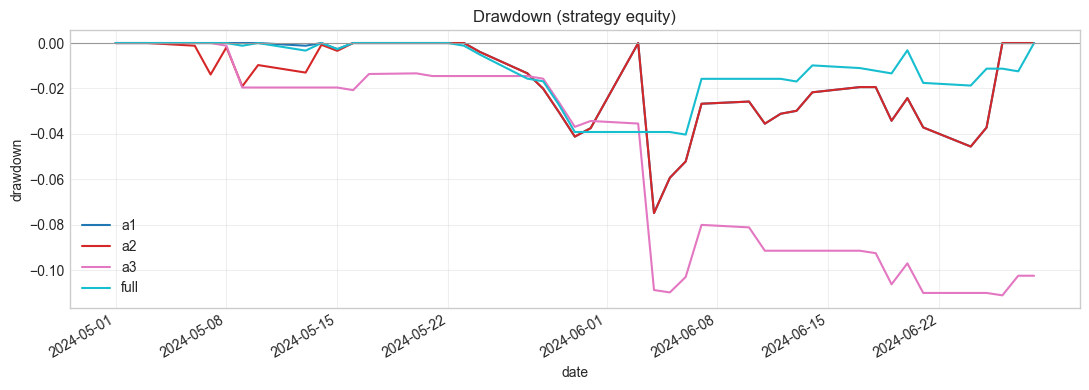

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
_colors = plt.cm.tab10(np.linspace(0, 1, max(len(DFS), 2)))
for i, ab in enumerate(DFS):
    df = DFS[ab]
    eq = df["equity"].astype(float)
    peak = eq.cummax()
    dd = np.where(peak > 0, eq / peak - 1.0, np.nan)
    ax.plot(df["date"], dd, label=ab, color=_colors[i], linewidth=1.5)

ax.axhline(0.0, color="0.6", lw=0.8)
ax.set_title("Drawdown (strategy equity)")
ax.set_xlabel("date")
ax.set_ylabel("drawdown")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Cumulative fees (when present)

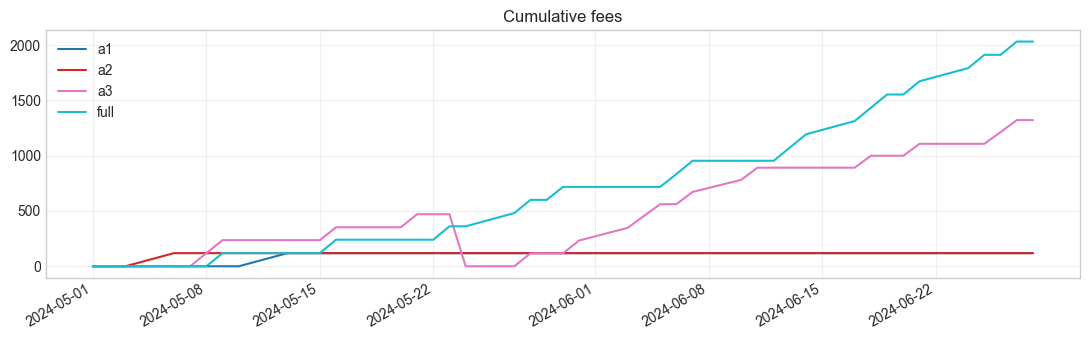

In [6]:
if any("cumulative_fees" in DFS[k].columns for k in DFS):
    fig, ax = plt.subplots(figsize=(11, 3.5))
    _colors = plt.cm.tab10(np.linspace(0, 1, max(len(DFS), 2)))
    for i, ab in enumerate(DFS):
        df = DFS[ab]
        if "cumulative_fees" not in df.columns:
            continue
        ax.plot(df["date"], df["cumulative_fees"].fillna(0), label=ab, color=_colors[i])
    ax.set_title("Cumulative fees")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
else:
    print("No cumulative_fees column in loaded frames.")